In [4]:
# Force white background
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'


✅ Plot saved: stress_over_time_per_block.png


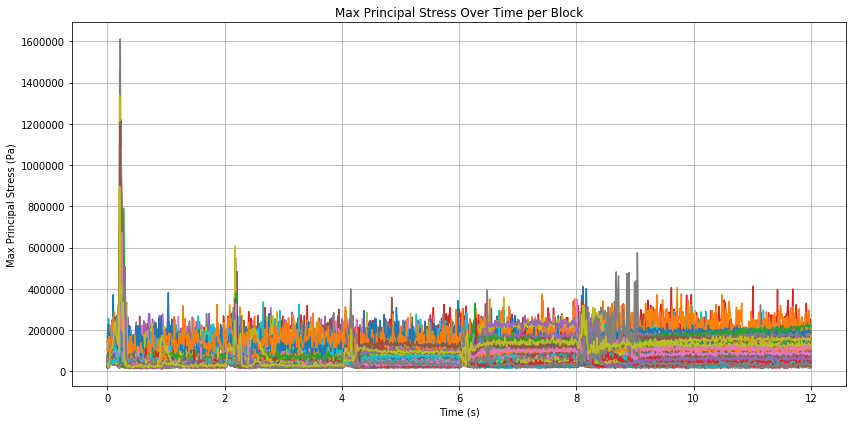

In [5]:

# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd

# --- Load CSV ---
csv_path = 'max_principal_stress_per_block_H06.csv'
df = pd.read_csv(csv_path)

# --- Extract time and block columns ---
time = df['Time']
block_columns = df.columns.drop('Time')
# print(df.head())
# --- Plot ---
plt.figure(figsize=(12, 6))

for block in block_columns:
    plt.plot(time, df[block], label=block)

plt.title("Max Principal Stress Over Time per Block")
plt.xlabel("Time (s)")
plt.ylabel("Max Principal Stress (Pa)")
plt.grid(True)
# plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.tight_layout()
# plt.savefig("stress_over_time_per_block.png")
print("✅ Plot saved: stress_over_time_per_block.png")
plt.show()



✅ Plot saved: stress_over_time_per_block.png


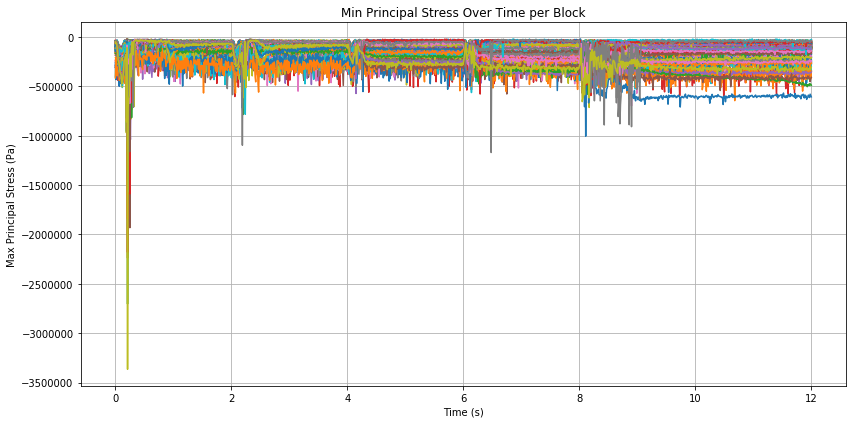

In [9]:

# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd

# --- Load CSV ---
csv_path = 'min_principal_stress_per_block_H06.csv'
df = pd.read_csv(csv_path)

# --- Extract time and block columns ---
time = df['Time']
block_columns = df.columns.drop('Time')
# print(df.head())
# --- Plot ---
plt.figure(figsize=(12, 6))

for block in block_columns:
    plt.plot(time, df[block], label=block)

plt.title("Min Principal Stress Over Time per Block")
plt.xlabel("Time (s)")
plt.ylabel("Max Principal Stress (Pa)")
plt.grid(True)
# plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.tight_layout()
# plt.savefig("stress_over_time_per_block.png")
print("✅ Plot saved: stress_over_time_per_block.png")
plt.show()



✅ Plot saved: stress_over_time_min_max.png


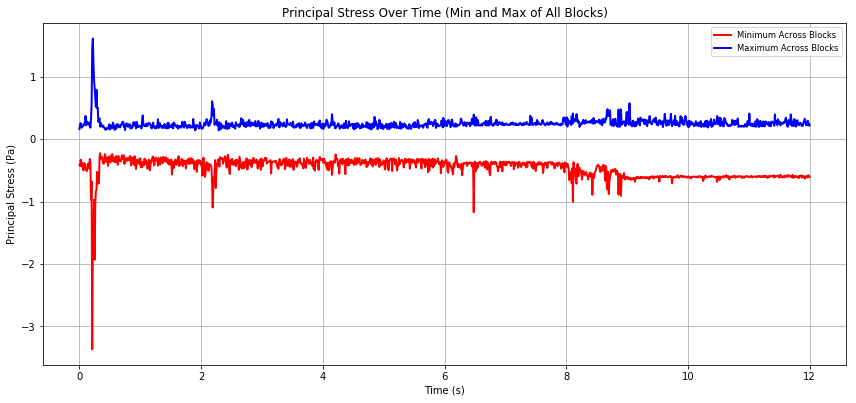

In [14]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd

# --- Load CSVs ---
csv_path_min = 'min_principal_stress_per_block_H06.csv'
csv_path_max = 'max_principal_stress_per_block_H06.csv'

# Load dataframes
df_min = pd.read_csv(csv_path_min)
df_max = pd.read_csv(csv_path_max)

# --- Extract time and block columns ---
time = df_min['Time']           # assuming both CSVs have identical time vectors
block_columns_min = df_min.columns.drop('Time')
block_columns_max = df_max.columns.drop('Time')

# --- Calculate min and max across blocks ---
min_across_blocks = df_min[block_columns_min].min(axis=1)
max_across_blocks = df_max[block_columns_max].max(axis=1)

# --- Plot ---
plt.figure(figsize=(12, 6))

# Plot the minimum line
plt.plot(time, min_across_blocks/1000000, color='red', linewidth=2, label='Minimum Across Blocks')

# Plot the maximum line
plt.plot(time, max_across_blocks/1000000, color='blue', linewidth=2, label='Maximum Across Blocks')

plt.title("Principal Stress Over Time (Min and Max of All Blocks)")
plt.xlabel("Time (s)")
plt.ylabel("Principal Stress (Pa)")
plt.grid(True)
plt.legend(loc='upper right', fontsize='small')
plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig("stress_over_time_min_max.png")
print("✅ Plot saved: stress_over_time_min_max.png")
plt.show()


✅ Saved: stress_blocks_t6.03s.png


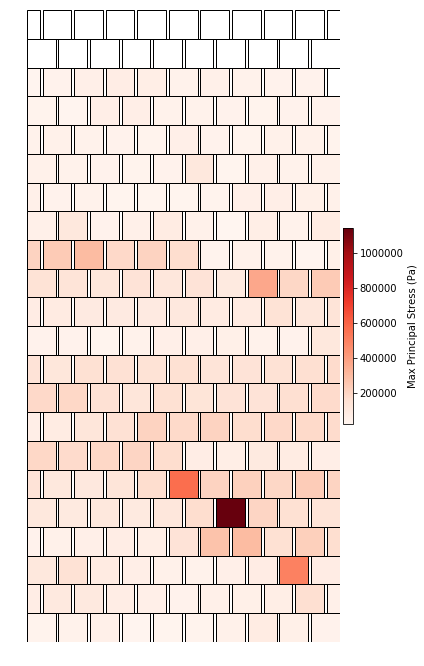

In [7]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import matplotlib.colors as mcolors
import numpy as np

# --- Settings ---
csv_path = 'max_principal_stress_per_block2.csv'
target_time = 6.03  # Time (s) to visualize

# --- Load CSV and get data for time step ---
df = pd.read_csv(csv_path)
df['Time'] = df['Time'].round(2)  # Round time for matching
row = df[df['Time'] == round(target_time, 2)]

if row.empty:
    raise ValueError("⛔ Time step {:.2f} not found in CSV.".format(target_time))

block_data = row.drop(columns='Time').iloc[0]
block_names = block_data.index.tolist()
block_values = block_data.values.astype(float)

# --- Normalize colors ---
norm = mcolors.Normalize(vmin=np.nanmin(block_values), vmax=np.nanmax(block_values))
cmap = plt.cm.Reds

# --- Block layout settings ---
full_w, full_h = 0.5, 0.5
half_w, half_h = 0.225, 0.5
h_spacing = 0.05
v_spacing = 0.0
rows = 22

# --- Initialize plot ---
fig, ax = plt.subplots(figsize=(6, 12))
current_y = 0
block_index = 0

for row_num in range(rows):
    if row_num % 2 == 0:
        # Even rows: 10 full blocks
        for i in range(10):
            x = i * (full_w + h_spacing)
            color = cmap(norm(block_values[block_index])) if block_index < len(block_values) else 'white'
            rect = patches.Rectangle((x, current_y), full_w, full_h, edgecolor='black', facecolor=color)
            ax.add_patch(rect)
            block_index += 1
    else:
        x = 0
        # First half block
        color = cmap(norm(block_values[block_index])) if block_index < len(block_values) else 'white'
        rect = patches.Rectangle((x, current_y), half_w, half_h, edgecolor='black', facecolor=color)
        ax.add_patch(rect)
        block_index += 1
        x += half_w + h_spacing
        # 9 full blocks
        for i in range(9):
            color = cmap(norm(block_values[block_index])) if block_index < len(block_values) else 'white'
            rect = patches.Rectangle((x, current_y), full_w, full_h, edgecolor='black', facecolor=color)
            ax.add_patch(rect)
            block_index += 1
            x += full_w + h_spacing
        # Final half block
        color = cmap(norm(block_values[block_index])) if block_index < len(block_values) else 'white'
        rect = patches.Rectangle((x, current_y), half_w, half_h, edgecolor='black', facecolor=color)
        ax.add_patch(rect)
        block_index += 1

    current_y += full_h + v_spacing

# --- Format figure ---
ax.set_aspect('equal')
ax.set_xlim(0, x + half_w)
ax.set_ylim(0, current_y)
ax.axis('off')

# --- Colorbar ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.01)
cbar.set_label('Max Principal Stress (Pa)')

# --- Save figure ---
plt.tight_layout()
out_name = f"stress_blocks_t{target_time:.2f}s.png"
# plt.savefig(out_name, dpi=300)
print("✅ Saved:", out_name)
plt.show()
